# Part 2: Differentiable Communication Systems

This tutorial will guide you through Sionna, from its basic principles to the implementation of a point-to-point link with a 5G NR compliant code and a 3GPP channel model.
You will also learn how to write custom trainable layers by implementing a state of the art neural receiver, and how to train and evaluate end-to-end communication systems.

The tutorial is structured in four notebooks:

- Part I: Getting started with Sionna

- **Part II: Differentiable Communication Systems**

- Part III: Advanced Link-level Simulations

- Part IV: Toward Learned Receivers

The [official documentation](https://nvlabs.github.io/sionna/index.html) provides key material on how to use Sionna and how its components are implemented.

* [Imports](#Imports)
* [Gradient Computation Through End-to-end Systems](#Gradient-Computation-Through-End-to-end-Systems)
* [Creating Custom Layers](#Creating-Custom-Layers)
* [Setting up Training Loops](#Setting-up-Training-Loops)

## Imports

In [ ]:
import os # Configure which GPU
if os.getenv("CUDA_VISIBLE_DEVICES") is None:
    gpu_num = 0 # Use "" to use the CPU
    os.environ["CUDA_VISIBLE_DEVICES"] = f"{gpu_num}"

# Import Sionna
try:
    import sionna as sn
    import sionna.phy
except ImportError as e:
    import sys
    if 'google.colab' in sys.modules:
       # Install Sionna in Google Colab
       print("Installing Sionna and restarting the runtime. Please run the cell again.")
       os.system("pip install sionna")
       os.kill(os.getpid(), 5)
    else:
       raise e

import numpy as np

# For plotting
%matplotlib inline
import matplotlib.pyplot as plt

# PyTorch imports for the implementation of the neural receiver
import torch
import torch.nn as nn
import torch.nn.functional as F

# Set seed for reproducible results
sn.phy.config.seed = 42

## Gradient Computation Through End-to-end Systems<a class="anchor" id="Gradient-Computation-Through-End-to-end-Systems"></a>

Let's start by setting up a simple communication system that transmit bits modulated as QAM symbols over an AWGN channel.

However, compared to what we have previously done, we now make the constellation
*trainable*. With Sionna, achieving this by assigning trainable points to a
`Constellation` instance.

In [ ]:
# Binary source to generate uniform i.i.d. bits
binary_source = sn.phy.mapping.BinarySource()

# 64-QAM constellation
NUM_BITS_PER_SYMBOL = 6
qam_constellation = sn.phy.mapping.Constellation("qam", NUM_BITS_PER_SYMBOL)

# Make a trainable constellation initialized with QAM points
# In PyTorch, we use tensors with requires_grad=True for trainable parameters
trainable_points = torch.stack([qam_constellation.points.real.clone(),
                                qam_constellation.points.imag.clone()], dim=0)
trainable_points.requires_grad_(True)

constellation = sn.phy.mapping.Constellation("custom",
                                             num_bits_per_symbol=NUM_BITS_PER_SYMBOL,
                                             points=torch.complex(trainable_points[0], trainable_points[1]),
                                             normalize=True,
                                             center=True)

# Mapper and demapper
mapper = sn.phy.mapping.Mapper(constellation=constellation)
demapper = sn.phy.mapping.Demapper("app", constellation=constellation)

# AWGN channel
awgn_channel = sn.phy.channel.AWGN()

As we have already seen, we can now easily simulate forward passes through the system we have just setup

In [ ]:
BATCH_SIZE = 128 # How many examples are processed by Sionna in parallel
EBN0_DB = 17.0 # Eb/N0 in dB

no = sn.phy.utils.ebnodb2no(ebno_db=EBN0_DB,
                        num_bits_per_symbol=NUM_BITS_PER_SYMBOL,
                        coderate=1.0) # Coderate set to 1 as we do uncoded transmission here

bits = binary_source([BATCH_SIZE,
                        1200]) # Blocklength
x = mapper(bits)
y = awgn_channel(x, no)
llr = demapper(y,no)

Just for fun, let's visualize the channel inputs and outputs

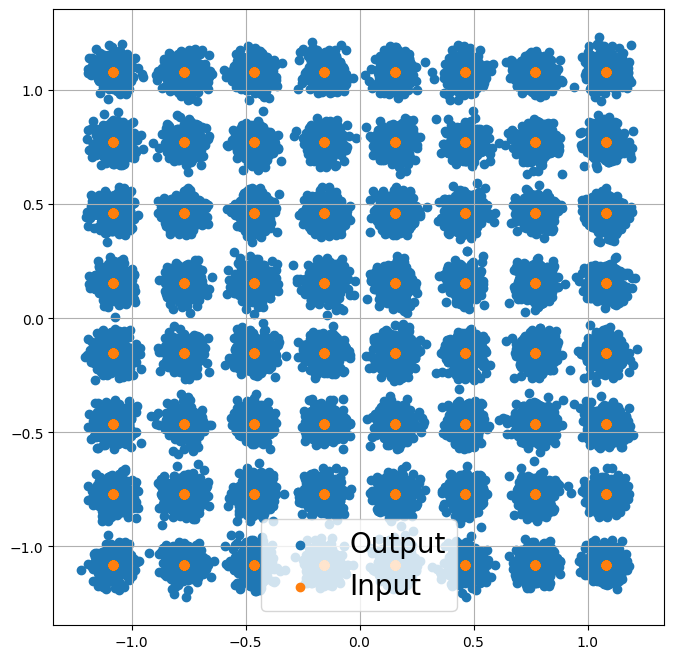

In [ ]:
plt.figure(figsize=(8,8))
plt.axes().set_aspect(1.0)
plt.grid(True)
plt.scatter(y.real.cpu().detach(), y.imag.cpu().detach(), label='Output')
plt.scatter(x.real.cpu().detach(), x.imag.cpu().detach(), label='Input')
plt.legend(fontsize=20);

Let's now *optimize* the constellation through *stochastic gradient descent* (SGD). As we will see, this is made very easy by Sionna.

We need to define a *loss function* that we will aim to minimize.

We can see the task of the receiver as jointly solving, for each received symbol, `NUM_BITS_PER_SYMBOL` binary classification problems in order to reconstruct the transmitted bits.
Therefore, a natural choice for the loss function is the *binary cross-entropy* (BCE) applied to each bit and to each received symbol.

*Remark:* The LLRs computed by the demapper are *logits* on the transmitted bits, and can therefore be used as-is to compute the BCE without any additional processing.
*Remark 2:* The BCE is closely related to an achieveable information rate for bit-interleaved coded modulation systems [1,2]

[1] Georg Böcherer, "Principles of Coded Modulation", [available online](http://www.georg-boecherer.de/bocherer2018principles.pdf)

[2] F. Ait Aoudia and J. Hoydis, "End-to-End Learning for OFDM: From Neural Receivers to Pilotless Communication," in IEEE Transactions on Wireless Communications, vol. 21, no. 2, pp. 1049-1063, Feb. 2022, doi: 10.1109/TWC.2021.3101364.

In [ ]:
# Compute Binary Cross-Entropy loss
# In PyTorch, we use F.binary_cross_entropy_with_logits
loss = F.binary_cross_entropy_with_logits(llr, bits.float())

print(f"BCE: {loss.item()}")

BCE: 0.00020045811834279448


One iteration of SGD consists in three steps:
1. Perform a forward pass through the end-to-end system and compute the loss function
2. Compute the gradient of the loss function with respect to the trainable weights
3. Apply the gradient to the weights

To enable gradient computation, we need to ensure our trainable parameters have `requires_grad=True`. PyTorch's autograd automatically tracks operations on such tensors.

In [ ]:
# Forward pass with gradient tracking (trainable_points has requires_grad=True)
bits = binary_source([BATCH_SIZE, 1200]) # Blocklength
mapper.constellation.points = torch.complex(trainable_points[0], trainable_points[1])
x = mapper(bits)
y = awgn_channel(x, no)
llr = demapper(y, no)
loss = F.binary_cross_entropy_with_logits(llr, bits.float())

Computing the gradient is done by calling `backward()` on the loss tensor. The gradients are then stored in the `.grad` attribute of each parameter.

In [ ]:
# Compute gradients by calling backward()
loss.backward()
# The gradient is stored in trainable_points.grad
gradient = trainable_points.grad

`gradient` is a tensor with the same shape as the trainable variable it corresponds to.

For this model, we only have a single trainable tensor: The constellation of shape [`2`, `2^NUM_BITS_PER_SYMBOL`], the first dimension corresponding to the real and imaginary components of the constellation points.

*Remark:* It is important to notice that the gradient computation was performed *through the demapper and channel*, which are conventional non-trainable algorithms implemented as *differentiable* Sionna blocks. This key feature of Sionna enables the training of end-to-end communication systems that combine both trainable and conventional and/or non-trainable signal processing algorithms.

In [ ]:
print(gradient.shape)

torch.Size([2, 64])


Applying the gradient (third step) is performed using an *optimizer*. [Many optimizers are available as part of PyTorch](https://pytorch.org/docs/stable/optim.html), and we use in this notebook ``Adam``.

In [ ]:
optimizer = torch.optim.Adam([trainable_points], lr=1e-2)

Using the optimizer, the gradients can be applied to the trainable weights to update them

In [ ]:
# Apply the gradients to update the trainable parameters
optimizer.step()

Let's compare the constellation before and after the gradient application

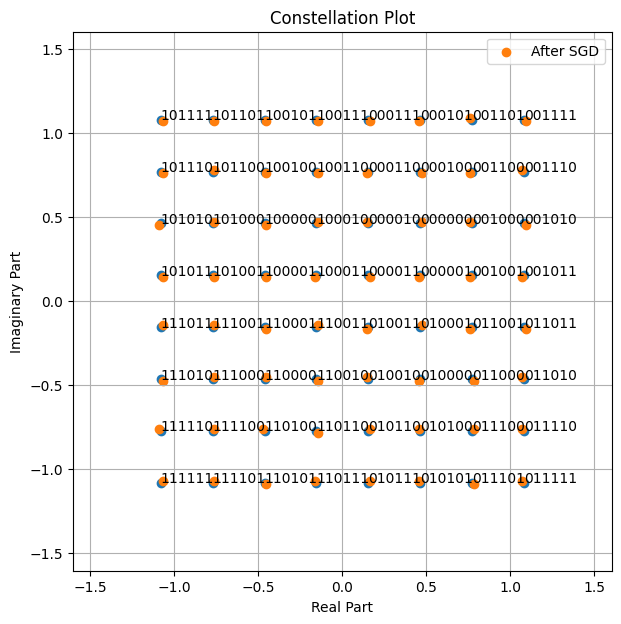

In [ ]:
fig = sn.phy.mapping.Constellation("qam", NUM_BITS_PER_SYMBOL).show()
fig.axes[0].scatter(trainable_points[0].detach().cpu(), trainable_points[1].detach().cpu(), label='After SGD')
fig.axes[0].legend();

The SGD step has led to slight change in the position of the constellation points. Training of a communication system using SGD consists in looping over such SGD steps until a stop criterion is met.

## Creating Custom Layers<a class="anchor" id="Creating-Custom-Layers"></a>

Custom trainable (or not trainable) algorithms can be implemented as [PyTorch
modules](https://pytorch.org/docs/stable/nn.html) (`nn.Module`) or Sionna
blocks. All Sionna components, such as the mapper, demapper, channel... are
implemented as Sionna blocks which enherit from the `nn.Module`.

To illustrate how this can be done, the next cell implements a simple neural network-based demapper which consists of three dense (linear) layers.

In [ ]:
class NeuralDemapper(nn.Module): # Inherits from PyTorch Module

    def __init__(self):
        super().__init__()

        # The three linear layers that form the custom trainable neural network-based demapper
        self.dense_1 = nn.Linear(2, 64)
        self.dense_2 = nn.Linear(64, 64)
        self.dense_3 = nn.Linear(64, NUM_BITS_PER_SYMBOL) # The last layer has no activation and therefore outputs logits, i.e., LLRs

    def forward(self, y):

        # y : complex-valued with shape [batch size, block length]
        # y is first mapped to a real-valued tensor with shape
        #  [batch size, block length, 2]
        # where the last dimension consists of the real and imaginary components
        # The linear layers operate on the last dimension, and treat the inner dimensions as batch dimensions, i.e.,
        # all the received symbols are independently processed.
        nn_input = torch.stack([y.real, y.imag], dim=-1)
        z = F.relu(self.dense_1(nn_input))
        z = F.relu(self.dense_2(z))
        z = self.dense_3(z) # [batch size, number of symbols per block, number of bits per symbol]
        llr = z.reshape(y.shape[0], -1) # [batch size, number of bits per block]
        return llr

A custom PyTorch module is used as any other Sionna layer, and therefore integration to a Sionna-based communication is straightforward.

The following model uses the neural demapper instead of the conventional demapper. It takes at initialization a parameter that indicates if the model is instantiated to be trained or evaluated. When instantiated to be trained, the loss function is returned. Otherwise, the transmitted bits and LLRs are returned.

In [ ]:
class End2EndSystem(nn.Module): # Inherits from PyTorch Module

    def __init__(self, training):

        super().__init__() # Must call the PyTorch module initializer

        qam_constellation = sn.phy.mapping.Constellation("qam", NUM_BITS_PER_SYMBOL)

        # Trainable constellation points as nn.Parameter
        self.points = nn.Parameter(torch.stack([qam_constellation.points.real.clone(),
                                                qam_constellation.points.imag.clone()], dim=0))

        self.constellation = sn.phy.mapping.Constellation("custom",
                                                    num_bits_per_symbol=NUM_BITS_PER_SYMBOL,
                                                    points=torch.complex(self.points[0], self.points[1]),
                                                    normalize=True,
                                                    center=True)
        self.mapper = sn.phy.mapping.Mapper(constellation=self.constellation)
        self.demapper = NeuralDemapper() # Instantiate the NeuralDemapper custom module as any other
        self.binary_source = sn.phy.mapping.BinarySource()
        self.awgn_channel = sn.phy.channel.AWGN()
        self._training_mode = training

    def forward(self, batch_size, ebno_db):

        # no channel coding used; we set coderate=1.0
        no = sn.phy.utils.ebnodb2no(ebno_db,
                                num_bits_per_symbol=NUM_BITS_PER_SYMBOL,
                                coderate=1.0)
        bits = self.binary_source([batch_size, 1200]) # Blocklength set to 1200 bits

        # Assign points to constellation
        self.mapper.constellation.points = torch.complex(self.points[0], self.points[1])

        x = self.mapper(bits)
        y = self.awgn_channel(x, no)
        llr = self.demapper(y)  # Call the NeuralDemapper custom module as any other
        if self._training_mode:
            loss = F.binary_cross_entropy_with_logits(llr, bits.float())
            return loss
        else:
            return bits, llr

When a model that includes a neural network is created, the neural network weights are randomly initialized typically leading to very poor performance.

To see this, the following cell benchmarks the previously defined untrained model against a conventional baseline.

EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 2.7044e-02 | 1.0000e+00 |        4154 |      153600 |          128 |         128 |         0.0 |reached target block errors
   10.526 | 2.0892e-02 | 1.0000e+00 |        3209 |      153600 |          128 |         128 |         0.0 |reached target block errors
   11.053 | 1.7057e-02 | 1.0000e+00 |        2620 |      153600 |          128 |         128 |         0.0 |reached target block errors
   11.579 | 1.2350e-02 | 1.0000e+00 |        1897 |      153600 |          128 |         128 |         0.0 |reached target block errors
   12.105 | 8.9062e-03 | 1.0000e+00 |        1368 |      153600 |          128 |         128 |         0.0 |reached target block errors
   12.632 | 6.8815e-03 | 1.0000e+00 |        1057 |      153600 |

   18.421 | 2.4089e-06 | 2.8906e-03 |          37 |    15360000 |           37 |       12800 |         0.1 |reached max iterations


   18.947 | 8.4635e-07 | 1.0156e-03 |          13 |    15360000 |           13 |       12800 |         0.1 |reached max iterations
   19.474 | 6.5104e-08 | 7.8125e-05 |           1 |    15360000 |            1 |       12800 |         0.1 |reached max iterations


     20.0 | 0.0000e+00 | 0.0000e+00 |           0 |    15360000 |            0 |       12800 |         0.1 |reached max iterations

Simulation stopped as no error occurred @ EbNo = 20.0 dB.

EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 5.2380e-01 | 1.0000e+00 |       80455 |      153600 |          128 |         128 |         0.1 |reached target block errors
   10.526 | 5.2522e-01 | 1.0000e+00 |       80674 |      153600 |          128 |         128 |         0.0 |reached target block errors
   11.053 | 5.2592e-01 | 1.0000e+00 |       80782 |      153600 |          128 |         128 |         0.0 |reached target block errors
   11.579 | 5.2693e-01 | 1.0000e+00 |       80937 |      153600 |          128 |         128 |         0.0 |reached target block errors
   12.105 

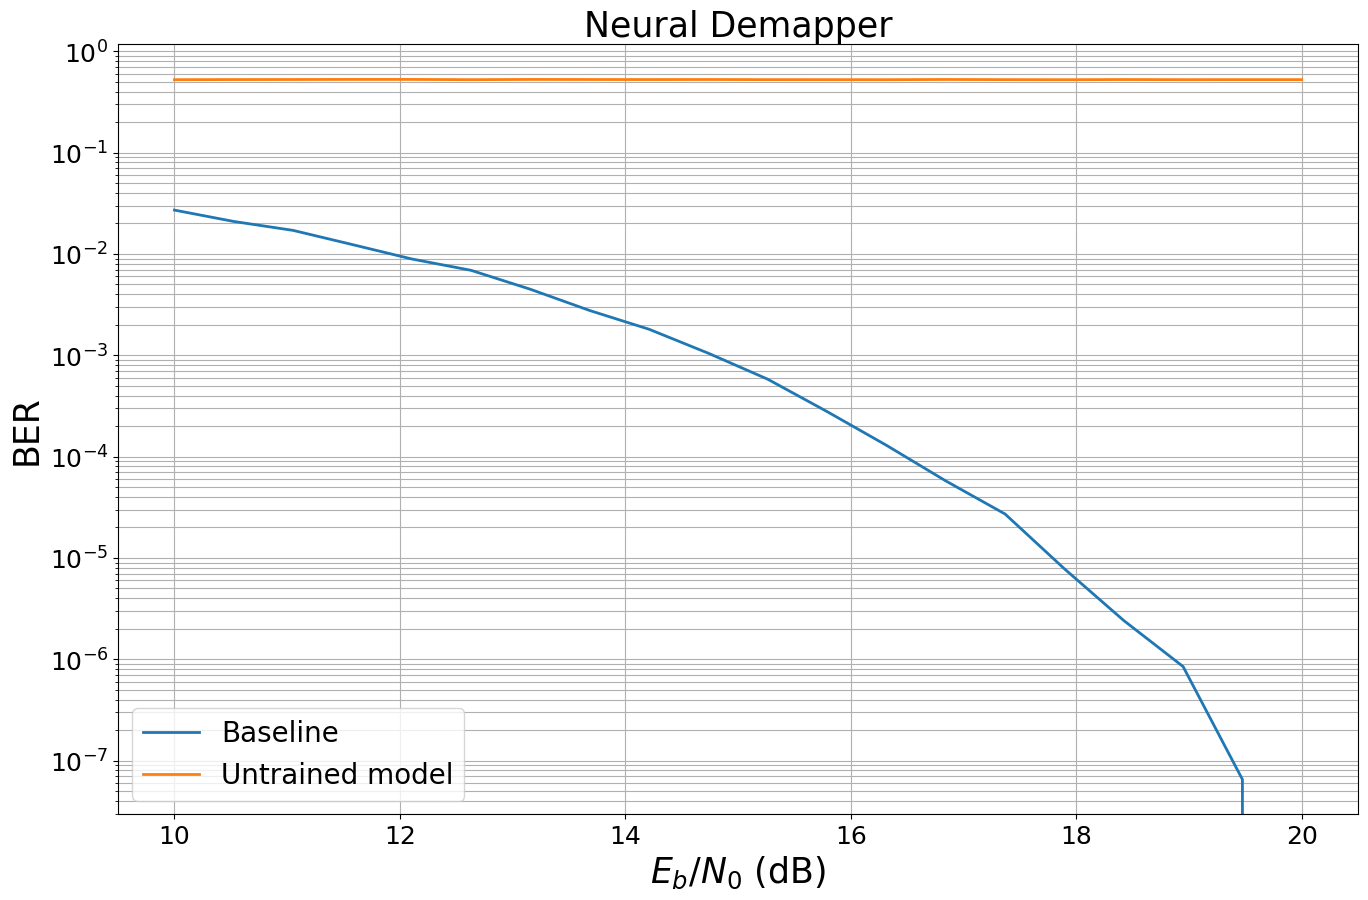

In [ ]:
EBN0_DB_MIN = 10.0
EBN0_DB_MAX = 20.0


###############################
# Baseline
###############################

class Baseline(nn.Module): # Inherits from PyTorch Module

    def __init__(self):

        super().__init__() # Must call the PyTorch module initializer

        self.constellation = sn.phy.mapping.Constellation("qam", NUM_BITS_PER_SYMBOL)
        self.mapper = sn.phy.mapping.Mapper(constellation=self.constellation)
        self.demapper = sn.phy.mapping.Demapper("app", constellation=self.constellation)
        self.binary_source = sn.phy.mapping.BinarySource()
        self.awgn_channel = sn.phy.channel.AWGN()

    def forward(self, batch_size, ebno_db):

        # no channel coding used; we set coderate=1.0
        no = sn.phy.utils.ebnodb2no(ebno_db,
                                num_bits_per_symbol=NUM_BITS_PER_SYMBOL,
                                coderate=1.0)
        bits = self.binary_source([batch_size, 1200]) # Blocklength set to 1200 bits
        x = self.mapper(bits)
        y = self.awgn_channel(x, no)
        llr = self.demapper(y, no)
        return bits, llr

###############################
# Benchmarking
###############################

baseline = Baseline()
model = End2EndSystem(False).to(sn.phy.config.device)  # Move model to GPU/CPU
ber_plots = sn.phy.utils.PlotBER("Neural Demapper")
ber_plots.simulate(baseline,
                  ebno_dbs=np.linspace(EBN0_DB_MIN, EBN0_DB_MAX, 20),
                  batch_size=BATCH_SIZE,
                  num_target_block_errors=100, # simulate until 100 block errors occurred
                  legend="Baseline",
                  soft_estimates=True,
                  max_mc_iter=100, # run 100 Monte-Carlo simulations (each with batch_size samples)
                  show_fig=False);
ber_plots.simulate(model,
                  ebno_dbs=np.linspace(EBN0_DB_MIN, EBN0_DB_MAX, 20),
                  batch_size=BATCH_SIZE,
                  num_target_block_errors=100, # simulate until 100 block errors occurred
                  legend="Untrained model",
                  soft_estimates=True,
                  max_mc_iter=100, # run 100 Monte-Carlo simulations (each with batch_size samples)
                  show_fig=True);

## Setting up Training Loops <a class="anchor" id="Setting-up-Training-Loops"></a>

Training of end-to-end communication systems consists in iterating over SGD steps.

The next cell implements a training loop of `NUM_TRAINING_ITERATIONS` iterations.
The training SNR is set to $E_b/N_0 = 15$ dB.

At each iteration:
- A forward pass through the end-to-end system is performed within a gradient tape
- The gradients are computed using the gradient tape, and applied using the Adam optimizer
- The estimated loss is periodically printed to follow the progress of training

In [ ]:
# Number of iterations used for training
NUM_TRAINING_ITERATIONS = 10000

# Instantiating the end-to-end model for training
model_train = End2EndSystem(training=True).to(sn.phy.config.device)

# Adam optimizer (SGD variant)
optimizer = torch.optim.Adam(model_train.parameters())

# Training loop
for i in range(NUM_TRAINING_ITERATIONS):
    # Zero gradients from previous iteration
    optimizer.zero_grad()
    # Forward pass
    loss = model_train(BATCH_SIZE, 15.0) # The model returns the loss
    # Backward pass to compute gradients
    loss.backward()
    # Apply gradients to update parameters
    optimizer.step()
    # Print progress
    if i % 100 == 0:
        print(f"{i}/{NUM_TRAINING_ITERATIONS}  Loss: {loss.item():.2E}", end="\r")

The weights of the trained model are saved using PyTorch's `torch.save()` function.

In [ ]:
# Save the weights in a file
torch.save(model_train.state_dict(), 'weights-neural-demapper.pt')

Finally, we evaluate the trained model and benchmark it against the previously introduced baseline.

We first instantiate the model for evaluation and load the saved weights.

In [ ]:
# Instantiating the end-to-end model for evaluation
model = End2EndSystem(training=False).to(sn.phy.config.device)
# Load the trained weights
model.load_state_dict(torch.load('weights-neural-demapper.pt', weights_only=True))

<All keys matched successfully>

The trained model is then evaluated.

EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 2.5781e-02 | 1.0000e+00 |        3960 |      153600 |          128 |         128 |         0.0 |reached target block errors
   10.526 | 2.0052e-02 | 1.0000e+00 |        3080 |      153600 |          128 |         128 |         0.0 |reached target block errors
   11.053 | 1.6204e-02 | 1.0000e+00 |        2489 |      153600 |          128 |         128 |         0.0 |reached target block errors
   11.579 | 1.2161e-02 | 1.0000e+00 |        1868 |      153600 |          128 |         128 |         0.0 |reached target block errors
   12.105 | 8.1771e-03 | 1.0000e+00 |        1256 |      153600 |          128 |         128 |         0.0 |reached target block errors
   12.632 | 5.7161e-03 | 1.0000e+00 |         878 |      153600 |

   18.421 | 2.4089e-06 | 2.8906e-03 |          37 |    15360000 |           37 |       12800 |         0.1 |reached max iterations
   18.947 | 8.4635e-07 | 1.0156e-03 |          13 |    15360000 |           13 |       12800 |         0.1 |reached max iterations


   19.474 | 2.6042e-07 | 3.1250e-04 |           4 |    15360000 |            4 |       12800 |         0.1 |reached max iterations
     20.0 | 6.5104e-08 | 7.8125e-05 |           1 |    15360000 |            1 |       12800 |         0.1 |reached max iterations


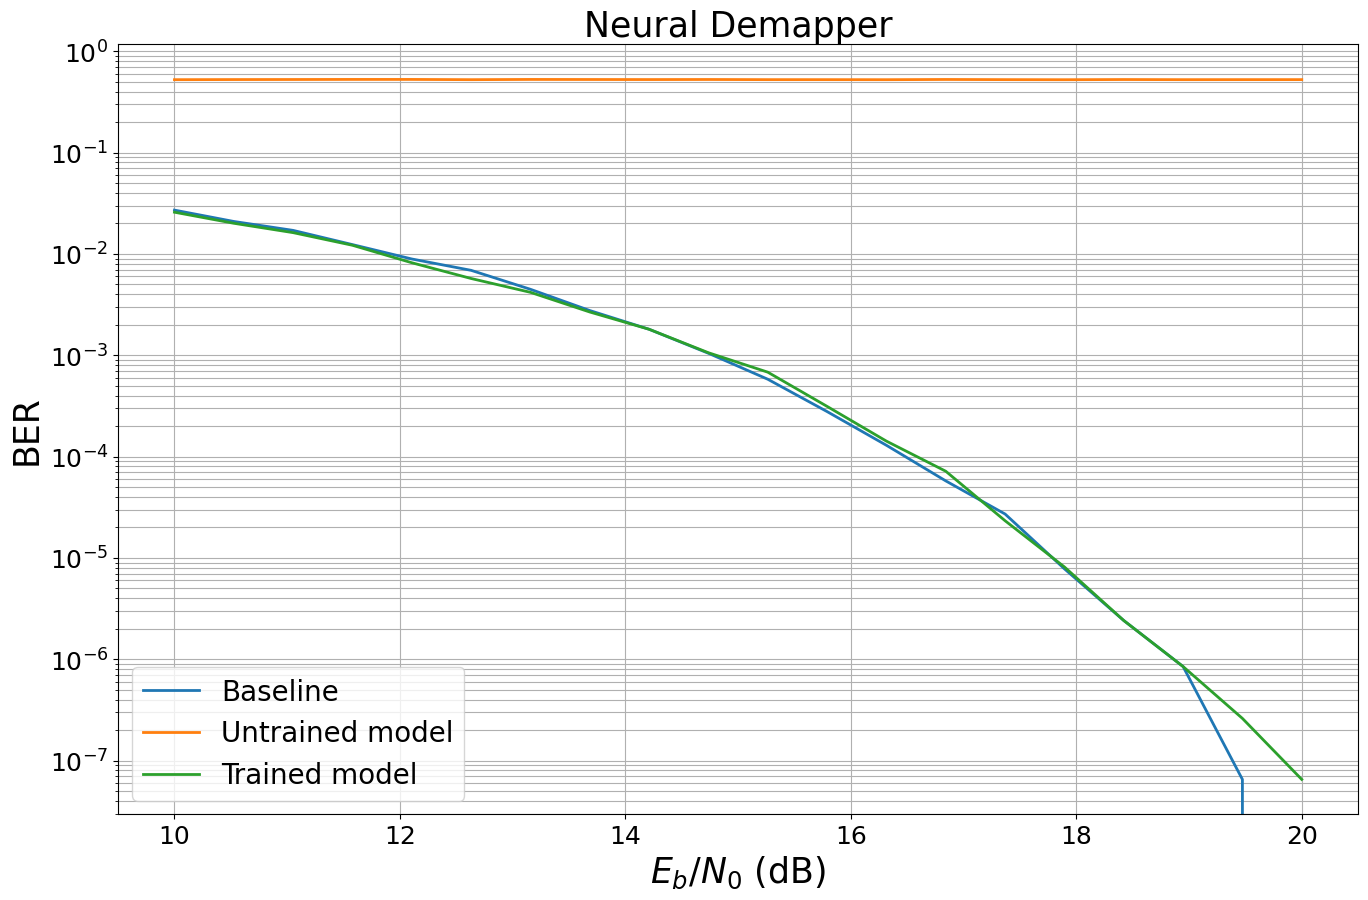

In [ ]:
# Computing and plotting BER
ber_plots.simulate(model,
                  ebno_dbs=np.linspace(EBN0_DB_MIN, EBN0_DB_MAX, 20),
                  batch_size=BATCH_SIZE,
                  num_target_block_errors=100,
                  legend="Trained model",
                  soft_estimates=True,
                  max_mc_iter=100,
                  show_fig=True);